In [1]:
from copy import deepcopy

import torch
from torch.utils.data import DataLoader

import xarray as xr

from tqdm.notebook import tqdm # sliders 

from neural_net import get_net # convolutional net 
from constants import * # meteo constants 

import matplotlib.pyplot as plt
import cartopy.crs as ccrs # for nice schemes of the earth 
import cartopy

In [2]:
torch.manual_seed(42)

# Settings

In [3]:
device = torch.device("cuda:0") # using only the first GPU (there are 2on kaitain) 
dtype = torch.bfloat16

In [4]:
batch_size = 512 # this can be big if we run on gpu 
# it's the way in which we split the training dataset to reduce computational cost 

n_epochs = 20 # 20 complete passes through the dataset 

n_layers = 4 # this will be used when calling the net 

# Load data

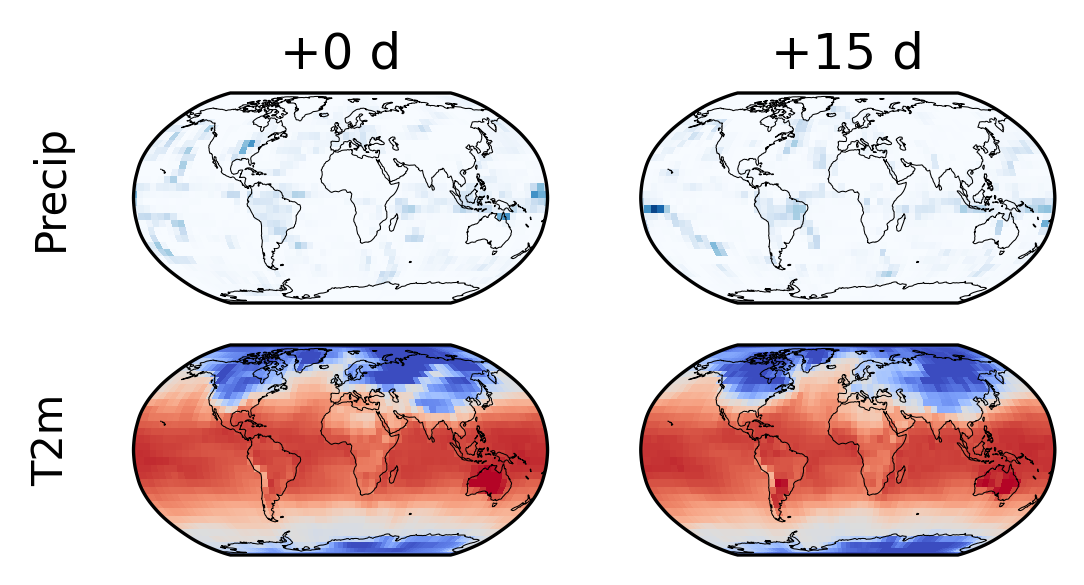

In [5]:
ds_train = xr.open_zarr("data/wb2_train.zarr")["geopotential"] # selecting geopotential data from the dataset 

fig, ax = plt.subplots(
    ncols=2, nrows=2, figsize=(4, 2),
    subplot_kw={"projection": ccrs.Robinson()},
    dpi=300
)
for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25) # we can add some features to the empty map. 
        # in this case coastlines
        # one can also have lakes etc but only in the US

# showing precipitation field on the first line of the plot 
ax[0, 0].text(x=-0.25, y=.55, s="Precip", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center") 
# showing Temperature at 2 meters. Moving down one block in the picture 
ax[1, 0].text(x=-0.25, y=.55, s="T2m", rotation=90, transform=ax[1, 0].transAxes, ha="left", va="center")

# 60 times 6 hrs = (60/24)*6 days = 15 days 
for i, td in enumerate([0, 60]):
    ax[0, i].set_title("+{0:d} d".format(td//4))
    ax[0, i].pcolormesh( # for plotting gridded data on the map. Coloring by value. 
        ds_train["longitude"], ds_train["latitude"], ds_train[td, -1].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[1, i].pcolormesh(
        ds_train["longitude"], ds_train["latitude"], ds_train[td, -2].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-30, vmax=30
    )

Training data: 1979 - 2017

Validation data: 2018 & 2019

In [6]:
# workers: we use 16 parallel threads / processes 
ds_train = xr.open_zarr("data/wb2_train.zarr")["geopotential"].compute(num_workers=16)

# Normalize data
# torch.cat = concatenate the two tensors 
train_data = torch.cat((
    # in_mean etc are defined in the constants file 
    # first line = normalization of the variables 
    (torch.as_tensor(ds_train.values[:-1], dtype=dtype)-in_mean) / in_std,
    # time_series[t] - time_series[t+1], normalized 
    (torch.as_tensor(ds_train.values[1:]-ds_train.values[:-1], dtype=dtype)-res_mean) / res_std 
), dim=1)

# we have concatenated normalized input data and normalized residuals 

del ds_train # remove from memory the initial data. Now everything is in train_data 

# this creates a pytorch data loader, which controls how data batches are fed to the model for training 
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
# why can we have suffle=True without breaking the physics? 

In [7]:
ds_val = xr.open_zarr("data/wb2_val.zarr")["geopotential"].compute(num_workers=16)
val_data = torch.cat((
    (torch.as_tensor(ds_val.values[:-1], dtype=dtype)-in_mean) / in_std,
    (torch.as_tensor(ds_val.values[1:]-ds_val.values[:-1], dtype=dtype)-res_mean) / res_std
), dim=1)
del ds_val

val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
weights_lat = torch.as_tensor(weights_lat, device=device, dtype=dtype)
# For doubly-periodic datasets no latitude weighting is required (weights_lat == 1.0)

# Define neural network

Use of a convolutional neural network

<img src="https://maucher.home.hdm-stuttgart.de/Pics/gif/same_padding_no_strides.gif" alt="A Conv layer." width="350"/>

<img src="fig02.png" alt="A typical CNN." width="1000"/>

## Content of neural_net.py

```
import torch
import torch.nn


class ConvNeXtBlock(torch.nn.Module):
    def __init__(self, n_features, mult=2):
        super().__init__()

        # geographic padding. vertical circular and zero horizontal padding 
        self.lon_pad = torch.nn.CircularPad2d((0, 0, 3, 3))
        self.lat_pad = torch.nn.ZeroPad2d((3, 3, 0, 0))

        # depthwise convolution
        self.conv_in = torch.nn.Conv2d(
            n_features, n_features, kernel_size=7, #larger kernel size than the classic CNN 
            # Larger receptive field --> can capture larger spatial pattern 
            padding=0
        )

        # normalization 
        self.norm = torch.nn.LayerNorm((n_features, 64, 32))
        self.branch_1 = torch.nn.Conv2d(n_features, n_features*mult, kernel_size=1)
        self.branch_2 = torch.nn.Sequential(
            torch.nn.Conv2d(n_features, n_features*mult, kernel_size=1),
            torch.nn.ReLU()
        )

        # proiezione output
        self.out_branch = torch.nn.Conv2d(n_features*mult, n_features, kernel_size=1)
        # learnable parameter 
        self.gamma = torch.nn.Parameter(torch.zeros(n_features, 1, 1))

    def forward(self, in_tensor):
        padded_tensor = self.lon_pad(in_tensor)
        padded_tensor = self.lat_pad(padded_tensor)
        spatial_tensor = self.conv_in(padded_tensor)
        normed_tensor = self.norm(spatial_tensor)
        branch_tensor = self.branch_1(normed_tensor) * self.branch_2(normed_tensor)
        out_tensor = self.out_branch(branch_tensor)
        return in_tensor + self.gamma * out_tensor


def get_net(n_layers=4, n_features=256, mult=2, device=None, dtype=torch.float32):
    convnet = torch.nn.Sequential(
        torch.nn.Conv2d(7, n_features, kernel_size=1),
        *[ConvNeXtBlock(n_features, mult) for _ in range(n_layers)],
        torch.nn.LayerNorm((n_features, 64, 32)),
        torch.nn.Conv2d(n_features, 7, kernel_size=1),
    )
    if device is None:
        device = torch.device("cpu")
    convnet = convnet.to(device=device, dtype=dtype)
    return convnet
```

In [9]:
convnet = get_net(
    n_layers=n_layers, n_features=256, mult=2, device=device, dtype=dtype
)
optim = torch.optim.Adam(convnet.parameters(), lr=1E-3) # we use the Adam optimizer here too

In [10]:
pbar_epoch = tqdm(range(n_epochs)) 

mse_val = torch.inf # initial mse value = infinity
best_mse = torch.inf
best_model = None # we'll select the best model when the minimum of the loss is reached 

for _ in pbar_epoch:
    pbar_train = tqdm(iter(train_loader), total=len(train_loader), leave=True)
    # Training loop
    convnet = convnet.train()
    for batch in pbar_train:        
        batch = batch.to(device=device, dtype=dtype)
        data_in, data_target = batch.split((7, 7), dim=1)

        optim.zero_grad()
        prediction = convnet(data_in)
        error = (prediction - data_target).pow(2)
        mse_train = (weights_lat * error).mean()
        mse_train.backward()
        optim.step()

        pbar_train.set_postfix(mse_train=mse_train.item(), mse_val=mse_val)

    mse_val = 0 # why set to zero now? 
    samples_val = 0
    pbar_val = tqdm(enumerate(val_loader), total=len(val_loader), leave=False)
    
    # Validation loop
    convnet = convnet.eval()
    for k, batch in pbar_val:        
        batch = batch.to(device=device, dtype=dtype)
        data_in, data_target = batch.split((7, 7), dim=1)
        
        with torch.no_grad():
            prediction = convnet(data_in)
        error = (prediction - data_target).pow(2)
        curr_se = (weights_lat * error).mean(dim=(1, 2, 3)).sum().item()
        mse_val = mse_val * samples_val + curr_se
        samples_val = samples_val + len(batch)
        mse_val = mse_val / samples_val

    pbar_train.set_postfix(mse_train=mse_train.item(), mse_val=mse_val)
        
    # Check if new model is better
    if mse_val < 0.999 * best_mse:
        best_mse = mse_val
        best_model = deepcopy(convnet).cpu()

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/112 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/112 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/112 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/112 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Store best model

In [ ]:
state_dict = convnet.cpu().state_dict()
torch.save(state_dict, "data/best_model.ckpt")